In [0]:
df = spark.read.format("binaryFile").load("/Volumes/ai_parse/sample/pdfs/sample-500kb.pdf")

In [0]:
import pyspark.sql.functions as F
parsed_df =  df.withColumn("parsed_text",F.expr("""
                                         ai_parse_document(content, MAP(
                                         'version', '2.0',
                                         'imageOutputPath', '/Volumes/ai_parse/sample/pdfs/parsed_images'
                                         ))
                                         """))
parsed_df = parsed_df.drop("content")
display(parsed_df)

path modificationTime length parsed_text dbfs:/Volumes/ai_parse/sample/pdfs/sample-500kb.pdf 2026-06-20T11:06:58.000Z 511993 {"document":{"elements":[{"bbox":[{"coord":[109,63,755,131],"page_id":0}],"confidence":0.9996,"content":"SAMPLE PDF FILE","description":null,"id":0,"type":"title"},{"bbox":[{"coord":[109,188,747,227],"page_id":0}],"confidence":0.9997,"content":"500 KB · 5,12,000 bytes · Text + Images","description":null,"id":1,"type":"text"},{"bbox":[{"coord":[703,410,852,590],"page_id":0}],"confidence":0.9999,"content":"","description":"A rectangular frame contains a landscape scene with mountains and a sun, set above three horizontal lines.","id":2,"type":"figure"},{"bbox":[{"coord":[583,671,974,757],"page_id":0}],"confidence":0.9464,"content":"500 KB Sample PDF · Text + Image","description":null,"id":3,"type":"text"},{"bbox":[{"coord":[111,775,384,812],"page_id":0}],"confidence":1,"content":"File Information","description":null,"id":4,"type":"section_header"},{"bbox":[{"coord":[109,854,980,1235],"page_id":0}],"confidence":0.9974,"content":" File Name: sample-500kb.pdf File Size: 5,12,000 bytes (500 KB) Format: PDF 1.7 Pages: 2 Content: Text + Embedded PNG Images Created By: QwikPDF Browser Generator Purpose: Web form upload limits, light CMS document testing Generated: Sat, 20 Jun 2026 11:04:57 GMT ","description":null,"id":5,"type":"table"},{"bbox":[{"coord":[111,2284,716,2313],"page_id":0}],"confidence":0.316,"content":"OverFD3 -speechman Free PDF ToPS Text - Image Sample","description":null,"id":6,"type":"page_footer"},{"bbox":[{"coord":[1443,2287,1555,2316],"page_id":0}],"confidence":1,"content":"Page 1 of 2","description":null,"id":7,"type":"page_number"},{"bbox":[{"coord":[107,26,511,78],"page_id":1}],"confidence":0.9998,"content":"Content & Charts Page","description":null,"id":8,"type":"title"},{"bbox":[{"coord":[1024,34,1343,76],"page_id":1}],"confidence":0.9998,"content":"QwikPDF · sample-500kb.pdf","description":null,"id":9,"type":"text"},{"bbox":[{"coord":[105,107,408,146],"page_id":1}],"confidence":0.9998,"content":"Section 1: Overview","description":null,"id":10,"type":"section_header"},{"bbox":[{"coord":[105,157,592,392],"page_id":1}],"confidence":0.9865,"content":"Lorem ipsum dolor sit amet, consectetur\nadipiscing elit. Sed do eiusmod tempor\nincididunt ut labore et dolore magna aliqua.\nUt enim ad minim veniam, quis nostrud\nexercitation ullamco laboris nisi ut aliquip\nex ea commodo consequat.","description":null,"id":11,"type":"text"},{"bbox":[{"coord":[913,149,1585,467],"page_id":1}],"confidence":0.9906,"content":"Figure 1 — Sample Image\nBar chart & pie chart — QwikPDF sample content\nData A\nData B\nData C\nData D","description":"A bar chart and pie chart, both in green, are displayed side-by-side with labels for Data A, B, and C.","id":12,"type":"figure"},{"bbox":[{"coord":[910,480,1181,517],"page_id":1}],"confidence":1,"content":"Figure 1: Sample chart data","description":null,"id":13,"type":"caption"},{"bbox":[{"coord":[105,598,522,640],"page_id":1}],"confidence":0.9999,"content":"Section 2: Technical Details","description":null,"id":14,"type":"section_header"},{"bbox":[{"coord":[105,647,1066,804],"page_id":1}],"confidence":0.982,"content":"Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat\nnulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia\ndeserunt mollit anim id est laborum. Sed ut perspiciatis unde omnis iste natus error sit\nvoluptatem accusantium doloremque laudantium.","description":null,"id":15,"type":"text"},{"bbox":[{"coord":[138,867,1125,974],"page_id":1}],"confidence":0.9932,"content":"This PDF (500 KB) was generated by QwikPDF browser generator. It contains real text content, embedded PNG images drawn on an HTML Canvas, and padding to reach the exact target file size of 5,12,000 bytes. Safe to use in all PDF viewers.","description":null,"id":16,"type":"text"},{"bbox":[{"coord":[105,2282,719,2318],"page_id"

In [0]:
dbutils.fs.ls("/Volumes/ai_parse/sample/pdfs/parsed_images")

[FileInfo(path='dbfs:/Volumes/ai_parse/sample/pdfs/parsed_images/b19b8510f51a3fc25e90b94bc257c69f242babd7651d26dd8f6153e46923b8e8.jpg', name='b19b8510f51a3fc25e90b94bc257c69f242babd7651d26dd8f6153e46923b8e8.jpg', size=170554, modificationTime=1781953654000),
 FileInfo(path='dbfs:/Volumes/ai_parse/sample/pdfs/parsed_images/f5ec4cc8f5a149a176522b9e6edba974de91b3ae15e6949031a8b67499a29d09.jpg', name='f5ec4cc8f5a149a176522b9e6edba974de91b3ae15e6949031a8b67499a29d09.jpg', size=138251, modificationTime=1781953654000)]

In [0]:
meta_df = parsed_df.select("path", "modificationTime", "length",
                        F.expr("parsed_text:document:pages"),
                        F.expr("parsed_text:document:elements"),
                        F.expr("parsed_text:error_status"),
                        F.expr("parsed_text:corrupted_data"),
                        F.expr("parsed_text:metadata"))
display(meta_df)
# meta_df.write.mode("overwrite").saveAsTable("pdfs_parsed")
# display(meta_df)
# display(parsed_df.select("parsed_text"))
# display(parsed_df

path modificationTime length pages elements error_status corrupted_data metadata dbfs:/Volumes/ai_parse/sample/pdfs/sample-500kb.pdf 2026-06-20T11:06:58.000Z 511993 [{"id":0,"image_uri":"/Volumes/ai_parse/sample/pdfs/parsed_images/f5ec4cc8f5a149a176522b9e6edba974de91b3ae15e6949031a8b67499a29d09.jpg"},{"id":1,"image_uri":"/Volumes/ai_parse/sample/pdfs/parsed_images/b19b8510f51a3fc25e90b94bc257c69f242babd7651d26dd8f6153e46923b8e8.jpg"}] [{"bbox":[{"coord":[109,63,755,131],"page_id":0}],"confidence":0.9996,"content":"SAMPLE PDF FILE","description":null,"id":0,"type":"title"},{"bbox":[{"coord":[109,188,747,227],"page_id":0}],"confidence":0.9997,"content":"500 KB · 5,12,000 bytes · Text + Images","description":null,"id":1,"type":"text"},{"bbox":[{"coord":[703,410,852,590],"page_id":0}],"confidence":0.9999,"content":"","description":"A rectangular frame contains a landscape scene with mountains and a sun, positioned above three horizontal lines.","id":2,"type":"figure"},{"bbox":[{"coord":[583,671,974,757],"page_id":0}],"confidence":0.9532,"content":"500 KB Sample PDF · Text + Image","description":null,"id":3,"type":"text"},{"bbox":[{"coord":[111,775,384,812],"page_id":0}],"confidence":1,"content":"File Information","description":null,"id":4,"type":"section_header"},{"bbox":[{"coord":[109,854,980,1235],"page_id":0}],"confidence":0.9974,"content":" File Name: sample-500kb.pdf File Size: 5,12,000 bytes (500 KB) Format: PDF 1.7 Pages: 2 Content: Text + Embedded PNG Images Created By: QwikPDF Browser Generator Purpose: Web form upload limits, light CMS document testing Generated: Sat, 20 Jun 2026 11:04:57 GMT ","description":null,"id":5,"type":"table"},{"bbox":[{"coord":[111,2284,716,2313],"page_id":0}],"confidence":0.3148,"content":"OverFD3 -speechman Free PDF ToPS Text - Image Sample","description":null,"id":6,"type":"page_footer"},{"bbox":[{"coord":[1443,2287,1555,2316],"page_id":0}],"confidence":1,"content":"Page 1 of 2","description":null,"id":7,"type":"page_number"},{"bbox":[{"coord":[107,26,511,78],"page_id":1}],"confidence":0.9998,"content":"Content & Charts Page","description":null,"id":8,"type":"title"},{"bbox":[{"coord":[1024,34,1343,76],"page_id":1}],"confidence":0.9999,"content":"QwikPDF · sample-500kb.pdf","description":null,"id":9,"type":"text"},{"bbox":[{"coord":[105,107,408,146],"page_id":1}],"confidence":0.9998,"content":"Section 1: Overview","description":null,"id":10,"type":"section_header"},{"bbox":[{"coord":[105,157,592,392],"page_id":1}],"confidence":0.9864,"content":"Lorem ipsum dolor sit amet, consectetur\nadipiscing elit. Sed do eiusmod tempor\nincididunt ut labore et dolore magna aliqua.\nUt enim ad minim veniam, quis nostrud\nexercitation ullamco laboris nisi ut aliquip\nex ea commodo consequat.","description":null,"id":11,"type":"text"},{"bbox":[{"coord":[913,149,1585,467],"page_id":1}],"confidence":0.9916,"content":"Figure 1 — Sample Image\nBar chart & pie chart — QwikPDF sample content\nData A\nData B\nData C\nData D","description":"A bar chart and pie chart display green-colored data labeled Data A, Data B, and Data C.","id":12,"type":"figure"},{"bbox":[{"coord":[910,480,1181,517],"page_id":1}],"confidence":1,"content":"Figure 1: Sample chart data","description":null,"id":13,"type":"caption"},{"bbox":[{"coord":[105,598,522,640],"page_id":1}],"confidence":0.9999,"content":"Section 2: Technical Details","description":null,"id":14,"type":"section_header"},{"bbox":[{"coord":[105,647,1066,804],"page_id":1}],"confidence":0.9823,"content":"Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat\nnulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia\ndeserunt mollit anim id est laborum. Sed ut perspiciatis unde omnis iste natus error sit\nvoluptatem accusantium doloremque laudantium.","description":null,"id":15,"type":"text"},{"bbox":[{"coord":[138,867,1125,974],"page_id":1}],"confidence":0.9937,"content":"This PDF (500 KB) was generated by QwikPDF

In [0]:
import os,sys
sys.path.append(os.path.abspath(".."))
from document_renderer import render_ai_parse_output,render_ai_parse_output_interactive

File Name:,sample-500kb.pdf
File Size:,"5,12,000 bytes (500 KB)"
Format:,PDF 1.7
Pages:,2
Content:,Text + Embedded PNG Images
Created By:,QwikPDF Browser Generator
Purpose:,"Web form upload limits, light CMS document testing"
Generated:,"Sat, 20 Jun 2026 11:04:57 GMT"

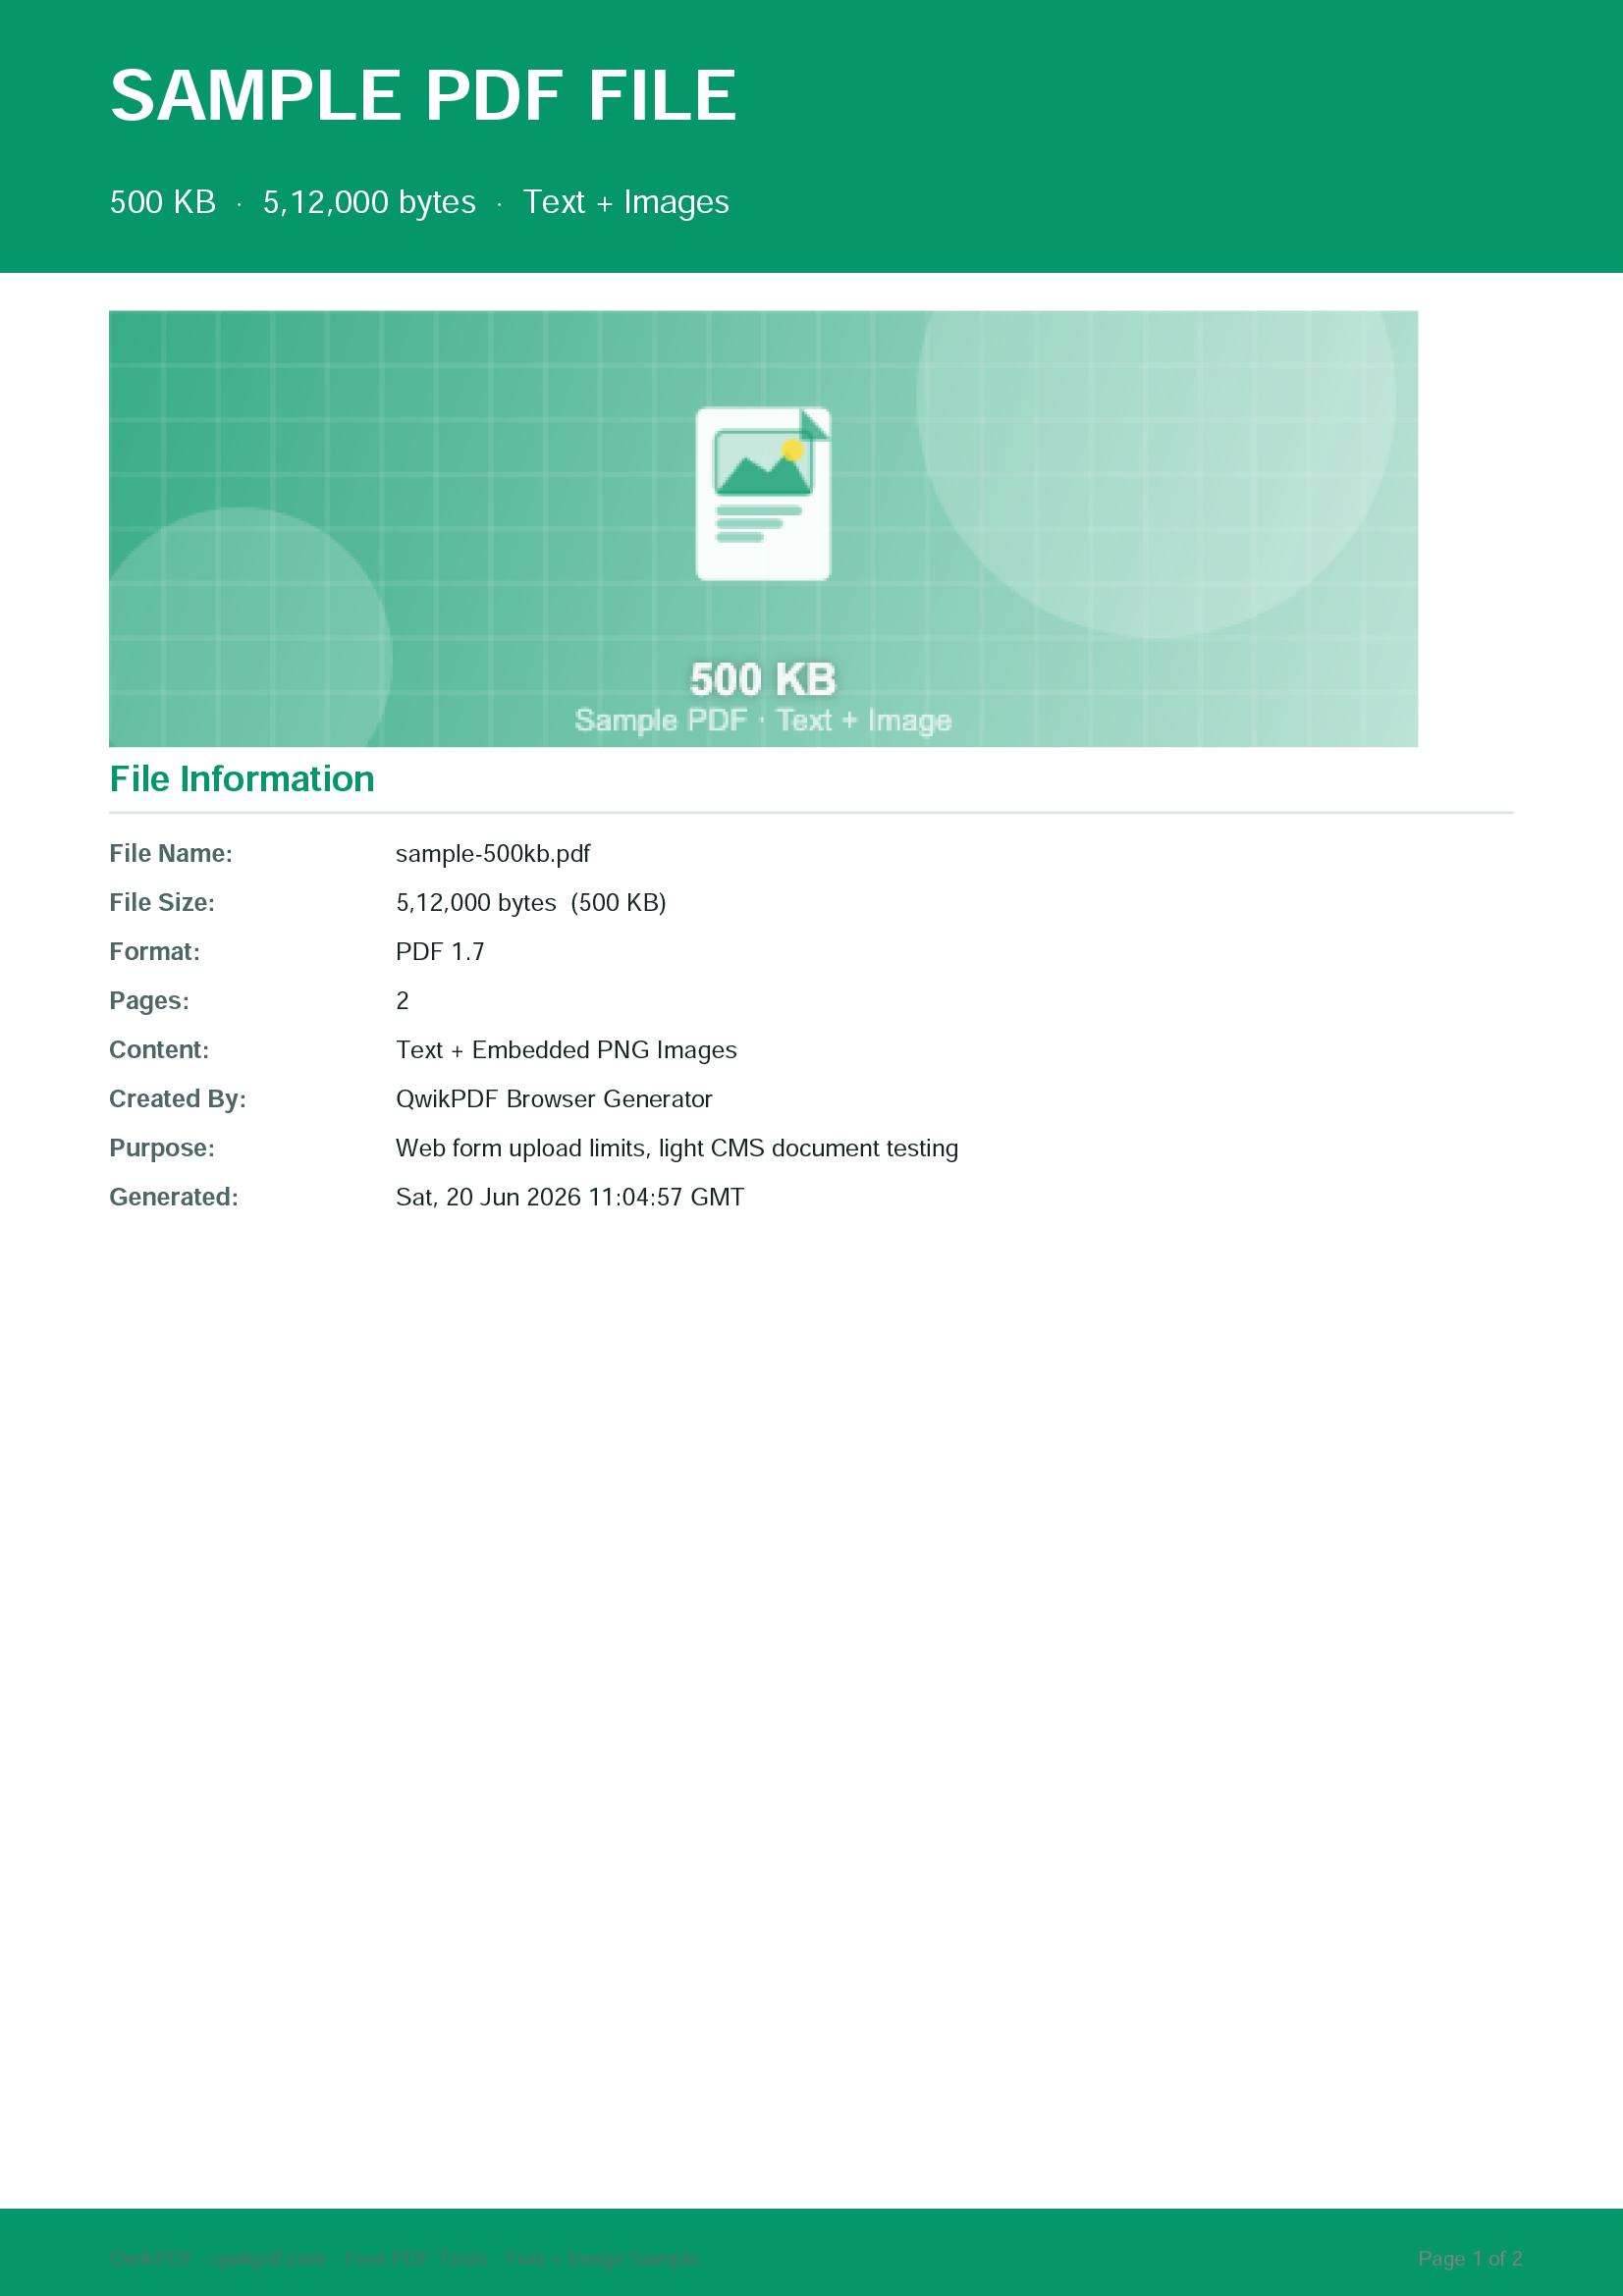

File Name:,sample-500kb.pdf
File Size:,"5,12,000 bytes (500 KB)"
Format:,PDF 1.7
Pages:,2
Content:,Text + Embedded PNG Images
Created By:,QwikPDF Browser Generator
Purpose:,"Web form upload limits, light CMS document testing"
Generated:,"Sat, 20 Jun 2026 11:04:57 GMT"



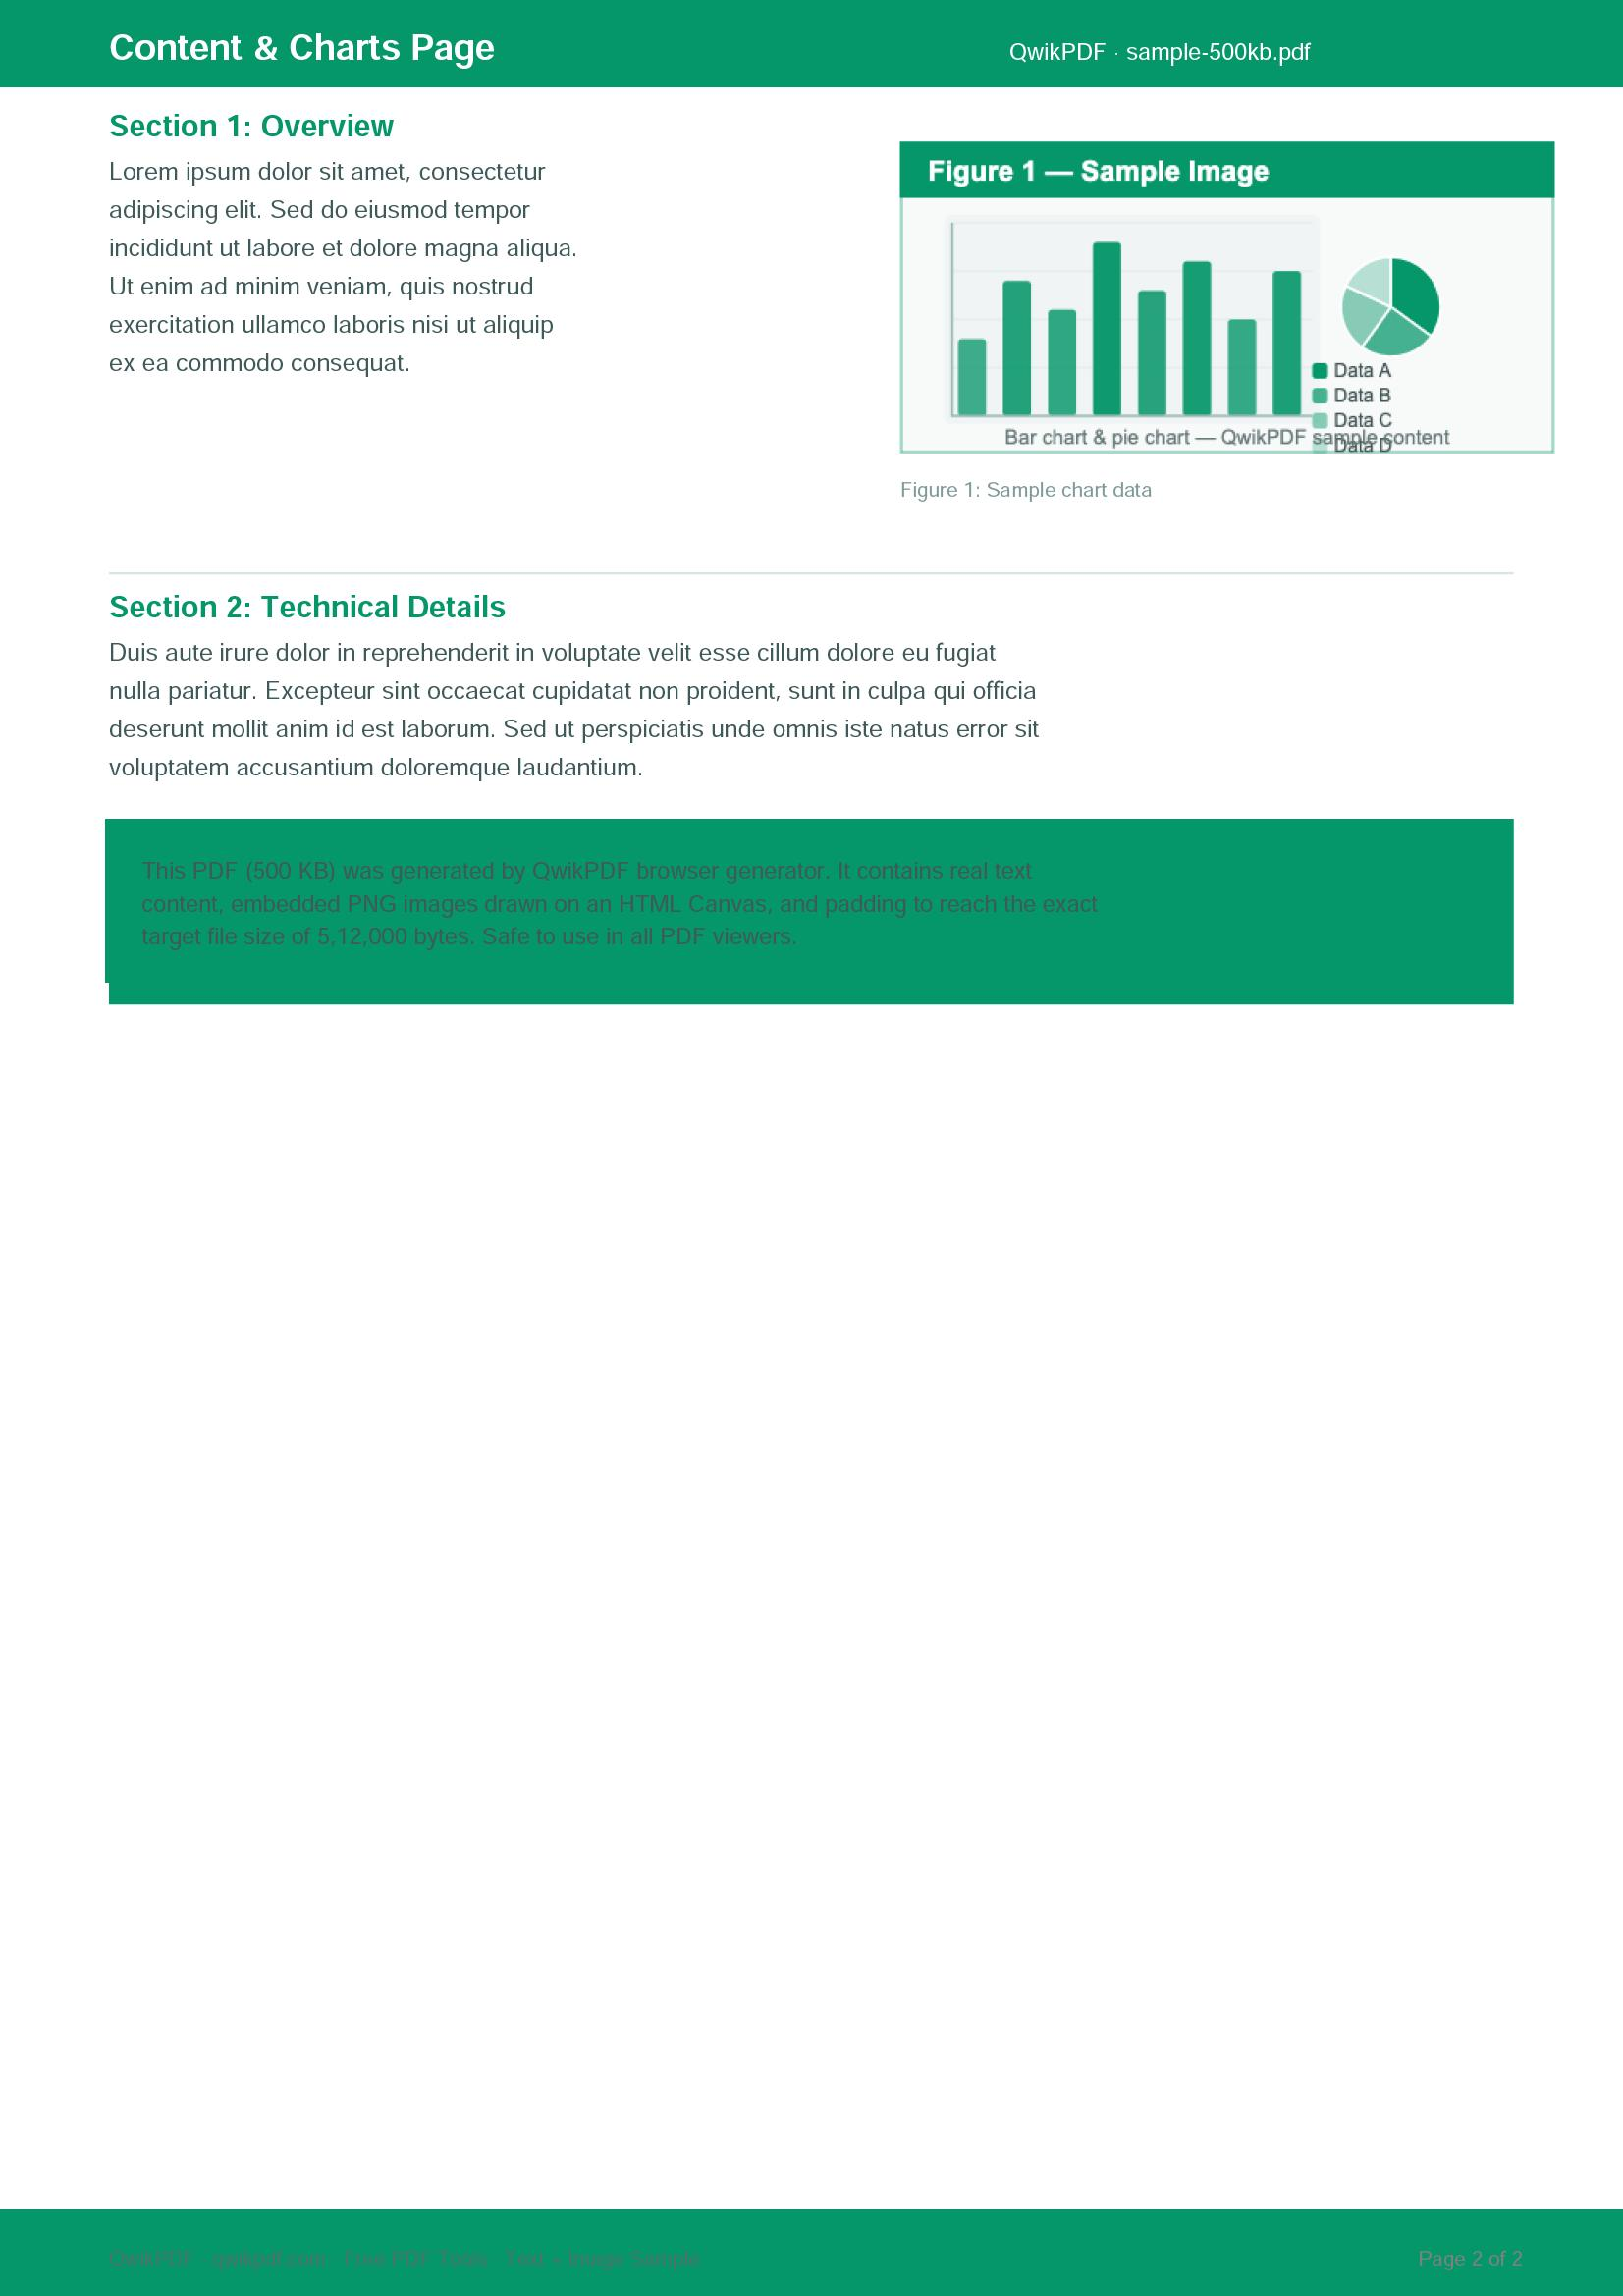

In [0]:
parsed_df.select("parsed_text").collect()[0][0]
display(render_ai_parse_output(parsed_df.select("parsed_text").collect()[0][0]))

In [0]:
parsed_df.write.format("delta").mode("overwrite").saveAsTable("ai_parse.sample.docs_parsed")